# Logistic Regression From Scratch

Logistic regression implemented end to end in numpy, with no scikit-learn model involved. The point is to build every piece by hand: the sigmoid, parameter initialization, forward and backward propagation, the gradient descent loop, and prediction, then assemble them into a working classifier.

Framing the model this way, as a single neuron with a sigmoid activation, is what makes it the natural on-ramp to a full neural network. The forward pass, the cost, and the gradients are the same machinery, just without a hidden layer.

The implementation is vectorised throughout, with no Python loops over training examples.

Structure follows the approach in Andrew Ng's [Neural Networks and Deep Learning](https://www.coursera.org/learn/neural-networks-deep-learning) course.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

%matplotlib inline

## 1. Loading the dataset and preprocessing

The [Breast Cancer Wisconsin (diagnostic) dataset](https://scikit-learn.org/stable/datasets/index.html): 569 samples, 30 real-valued features, two classes (malignant and benign).

Features are standard-scaled with a scaler fit on the training split only, then both matrices are transposed so that columns are examples and rows are features. That orientation is what makes the whole implementation vectorise cleanly.


In [2]:
X, y = load_breast_cancer(return_X_y=True)
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size =0.2, random_state=0)

In [3]:
scaler = preprocessing.StandardScaler().fit(train_data)
train_data = scaler.transform(train_data)
test_data = scaler.transform(test_data)

In [4]:
trainx = train_data.T
trainy = train_labels.reshape(-1,1).T

testx = test_data.T
testy =test_labels.reshape(-1,1).T

In [5]:
trainx.shape, trainy.shape, testx.shape, testy.shape

((30, 455), (1, 455), (30, 114), (1, 114))

In [6]:
X=trainx
Y=trainy

In [7]:
shape_X = X.shape
shape_Y = Y.shape
m = X.shape[1]  # training set size

print ('No. of training samples: ' + str(m))
print ('Number of features per sample: ' + str(shape_X[0]))

No. of training samples: 455
Number of features per sample: 30


## 2. Building the parts of the model

The main steps for building the model:

1. Define the model structure, such as the number of input features
2. Initialize the model's parameters
3. Loop:
    - calculate the current loss (forward propagation)
    - calculate the current gradient (backward propagation)
    - update the parameters (gradient descent)

Each piece is built and tested on its own first, then integrated into a single function.

### 2.1 - Helper functions

First the sigmoid, $sigmoid(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$, which squashes any real value into $(0, 1)$ so the output can be read as a probability.


In [8]:
def sigmoid(z):
    """
    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """

    s = 1 / (1 + np.exp(-z))
    
    return s

In [9]:
print ("sigmoid([-2, 2]) = " + str(sigmoid(np.array([-2,2]))))

sigmoid([-2, 2]) = [0.11920292 0.88079708]


### 2.2 - Initialize the parameters of the model

For logistic regression, `w` is initialized as a vector of zeros and `b` as 0. Zero initialization is fine here precisely because there is no hidden layer: with a single neuron there is no symmetry between units to break, so every parameter still receives a distinct gradient. That stops being true for the neural network, where zero initialization would leave all hidden units identical forever.


In [10]:
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    
    Argument:
    dim -- size of the w vector we want (or number of parameters in this case)
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias)
    """
    
    w = np.zeros((dim, 1))
    b = 0.0

    assert(w.shape == (dim, 1))
    assert(isinstance(b, float) or isinstance(b, int))
    
    return w, b

In [11]:
dim = 2
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0.0


### 2.3 - Forward and backward propagation

With the parameters initialized, the next step is the forward and backward pass used to learn them.

Forward propagation takes $X$ and computes

$$A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$$

then the cost

$$J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$$

Backward propagation uses the two gradients

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T\tag{7}$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})\tag{8}$$

Both are computed in a single `propagate()` function, since the forward pass already produces the $A$ that the gradients need.


In [12]:
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for the propagation explained above

    Arguments:
    w -- weights, a numpy array
    b -- bias, a scalar
    X -- data 
    Y -- true "label" vector

    Return:
    cost -- negative log-likelihood cost for logistic regression
    dw -- gradient of the loss with respect to w, thus same shape as w
    db -- gradient of the loss with respect to b, thus same shape as b
    
    """
    
    m = X.shape[1]
    
    # FORWARD PROPAGATION (FROM X TO COST)
    A = sigmoid(np.dot(w.T, X) + b)                                    # compute activation
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))        # compute cost
    
    # BACKWARD PROPAGATION (TO FIND GRAD)
    dw = 1/m * np.dot(X, (A - Y).T)
    db = 1/m * np.sum(A - Y)

    assert(dw.shape == w.shape)
    assert(db.dtype == float)
    cost = np.squeeze(cost)
    assert(cost.shape == ())
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, cost

In [13]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[0.99845601]
 [2.39507239]]
db = 0.001455578136784208
cost = 5.801545319394553


### 2.4 - Optimization

The parameters are initialized and the cost and its gradient can be computed, so what remains is updating the parameters by gradient descent.

The goal is to learn $w$ and $b$ by minimizing $J$. For a parameter $\theta$ the update rule is $\theta = \theta - \alpha \text{ } d\theta$, where $\alpha$ is the learning rate.


In [14]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
    """
    This function optimizes w and b by running a gradient descent algorithm
    
    Arguments:
    w -- weights, a numpy array 
    b -- bias, a scalar
    X -- data 
    Y -- true "label" vector 
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 100 steps
    
    Returns:
    params -- dictionary containing the weights w and bias b
    grads -- dictionary containing the gradients of the weights and bias with respect to the cost function
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    
    """
    
    costs = []
    
    for i in range(num_iterations):
        
        
        # Cost and gradient calculation
        grads, cost = propagate(w, b, X, Y)
        
        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]
        
        # update rule
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        # Record the costs
        if i % 100 == 0:
            costs.append(cost)
        
        # Print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs

In [15]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = True)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))

Cost after iteration 0: 5.801545
w = [[0.19033591]
 [0.12259159]]
b = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067652


The optimization function returns the learned `w` and `b`, which are enough to predict labels for any dataset `X`. Prediction is two steps:

1. Compute $\hat{Y} = A = \sigma(w^T X + b)$
2. Threshold each entry at 0.5, giving 0 or 1


In [16]:
def predict(w, b, X):
    '''
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)
    
    Arguments:
    w -- weights, a numpy array 
    b -- bias, a scalar
    X -- data
    
    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''
    
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    
    # Compute vector "A" predicting the probabilities
    A = sigmoid(np.dot(w.T, X) + b)
    
    for i in range(A.shape[1]):
        
        # Convert probabilities A[0,i] to actual predictions p[0,i]
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0
    
    assert(Y_prediction.shape == (1, m))
    
    return Y_prediction

In [17]:
w = np.array([[0.1124579],[0.23106775]])
b = -0.3
X = np.array([[1.,-1.1,-3.2],[1.2,2.,0.1]])
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1. 0.]]


## 3. Merging everything into a single model

All the building blocks above are assembled into one `LogisticModel()` function, called in the right order: initialize, optimize, then predict on both the training and test sets.


In [18]:
def LogisticModel(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):
    """
    Builds the logistic regression model by calling the function you've implemented previously
    
    Arguments:
    X_train -- training set represented by a numpy array 
    Y_train -- training labels represented by a numpy array (vector) of shape (1, m_train)
    X_test -- test set represented by a numpy array 
    Y_test -- test labels represented by a numpy array (vector) of shape (1, m_test)
    num_iterations -- hyperparameter representing the number of iterations to optimize the parameters
    learning_rate -- hyperparameter representing the learning rate used in the update rule of optimize()
    print_cost -- Set to true to print the cost every 100 iterations
    
    Returns:
    d -- dictionary containing information about the model.
    """
    
    
    # initialize parameters with zeros 
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent 
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    # Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]
    
    # Predict test/train set examples 
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)
    

    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

Training the model on the breast cancer data:


In [19]:
d = LogisticModel(trainx, trainy, testx, testy, num_iterations = 1500, learning_rate = 0.01, print_cost = True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.251215
Cost after iteration 200: 0.187238
Cost after iteration 300: 0.158422
Cost after iteration 400: 0.141506
Cost after iteration 500: 0.130183
Cost after iteration 600: 0.121972
Cost after iteration 700: 0.115687
Cost after iteration 800: 0.110685
Cost after iteration 900: 0.106586
Cost after iteration 1000: 0.103151
Cost after iteration 1100: 0.100219
Cost after iteration 1200: 0.097679
Cost after iteration 1300: 0.095451
Cost after iteration 1400: 0.093477
train accuracy: 98.46153846153847 %
test accuracy: 96.49122807017544 %


Training accuracy sits close to 100%, which is the sanity check worth running first: it confirms the model has enough capacity to fit the data and that the gradients are wired up correctly. A model that cannot overfit its own training set usually has a bug rather than a bias problem.


Plotting the cost over the training run:


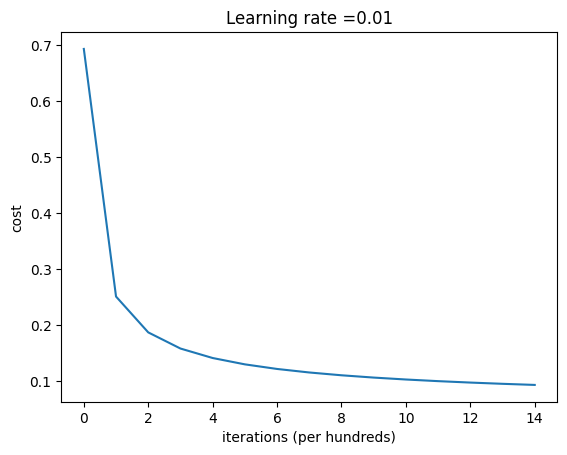

In [20]:
# Plot learning curve (with costs)
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

The cost decreases steadily, so the parameters are being learned. Training longer would push training accuracy higher still, but test accuracy would eventually start to fall behind. That gap is overfitting, and it is the reason the number of iterations is a hyper-parameter rather than something to maximize.


## References

- [Neural Networks and Deep Learning](https://www.coursera.org/learn/neural-networks-deep-learning)
- [Implementing a Neural Network from Scratch](http://www.wildml.com/2015/09/implementing-a-neural-network-from-scratch/)
